In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc

In [3]:
df = pd.read_csv("dataset.csv")
df.shape

(110110, 35)

In [4]:
df.head()

,Person_ID,Record_Date,Is_Weekend,Gender,Age,Occupation,BMI_Value,BMI_Category,Smoking_Status,Sleep_Duration_Hours,...,Blood_Pressure,Systolic_BP,Diastolic_BP,Daily_Steps,Caffeine_Intake_mg,Screen_Time_Before_Bed_Mins,Alcohol_Units_Per_Week,Room_Temperature_C,Noise_Level_dB,Sleep_Disorder
0,1,12/8/2023,0,Male,39,Manager,24.6,Normal,Never,7.5,...,145/87,145,87,4299,85,102,0.7,15.2,20,NaN
1,2,4/26/2020,0,Female,30,Police Officer,25.3,Overweight,Never,10.0,...,125/69,125,69,9369,158,93,5.6,20.4,43,NaN
2,3,1/11/2023,1,Female,71,Engineer,26.6,Overweight,Never,8.5,...,140/85,140,85,9379,64,51,2.9,13.7,31,NaN
3,4,3/25/2022,0,Female,22,Teacher,29.6,Overweight,Current,8.5,...,137/80,137,80,5937,68,78,0.5,23.2,41,NaN
4,5,6/11/2022,0,Male,63,Accountant,26.1,Overweight,Never,6.0,...,150/80,150,80,500,117,106,0.6,20.3,23,NaN


In [5]:
df['Sleep_Disorder'] = df['Sleep_Disorder'].replace({np.nan: 'None'})
# Missing values
df.isnull().sum().sort_values(ascending=False)
df.head()

,Person_ID,Record_Date,Is_Weekend,Gender,Age,Occupation,BMI_Value,BMI_Category,Smoking_Status,Sleep_Duration_Hours,...,Blood_Pressure,Systolic_BP,Diastolic_BP,Daily_Steps,Caffeine_Intake_mg,Screen_Time_Before_Bed_Mins,Alcohol_Units_Per_Week,Room_Temperature_C,Noise_Level_dB,Sleep_Disorder
0,1,12/8/2023,0,Male,39,Manager,24.6,Normal,Never,7.5,...,145/87,145,87,4299,85,102,0.7,15.2,20,None
1,2,4/26/2020,0,Female,30,Police Officer,25.3,Overweight,Never,10.0,...,125/69,125,69,9369,158,93,5.6,20.4,43,None
2,3,1/11/2023,1,Female,71,Engineer,26.6,Overweight,Never,8.5,...,140/85,140,85,9379,64,51,2.9,13.7,31,None
3,4,3/25/2022,0,Female,22,Teacher,29.6,Overweight,Current,8.5,...,137/80,137,80,5937,68,78,0.5,23.2,41,None
4,5,6/11/2022,0,Male,63,Accountant,26.1,Overweight,Never,6.0,...,150/80,150,80,500,117,106,0.6,20.3,23,None


In [6]:
df.shape


(110110, 35)

In [7]:
df["Sleep_Deficit"] = np.maximum(0, 8 - df["Sleep_Duration_Hours"])
df["Activity_Stress_Ratio"] = (df["Physical_Activity_Mins"] / (df["Stress_Level"] + 1)).round(2)

In [8]:
df.head()

,Person_ID,Record_Date,Is_Weekend,Gender,Age,Occupation,BMI_Value,BMI_Category,Smoking_Status,Sleep_Duration_Hours,...,Diastolic_BP,Daily_Steps,Caffeine_Intake_mg,Screen_Time_Before_Bed_Mins,Alcohol_Units_Per_Week,Room_Temperature_C,Noise_Level_dB,Sleep_Disorder,Sleep_Deficit,Activity_Stress_Ratio
0,1,12/8/2023,0,Male,39,Manager,24.6,Normal,Never,7.5,...,87,4299,85,102,0.7,15.2,20,None,0.5,4.00
1,2,4/26/2020,0,Female,30,Police Officer,25.3,Overweight,Never,10.0,...,69,9369,158,93,5.6,20.4,43,None,0.0,11.40
2,3,1/11/2023,1,Female,71,Engineer,26.6,Overweight,Never,8.5,...,85,9379,64,51,2.9,13.7,31,None,0.0,11.33
3,4,3/25/2022,0,Female,22,Teacher,29.6,Overweight,Current,8.5,...,80,5937,68,78,0.5,23.2,41,None,0.0,5.67
4,5,6/11/2022,0,Male,63,Accountant,26.1,Overweight,Never,6.0,...,80,500,117,106,0.6,20.3,23,None,2.0,0.50


In [9]:
df['Sleep_Disorder'].unique()


<ArrowStringArray>
['None', 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

In [10]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 110110 entries, 0 to 110109
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Person_ID                    110110 non-null  int64  
 1   Record_Date                  110110 non-null  str    
 2   Is_Weekend                   110110 non-null  int64  
 3   Gender                       110110 non-null  str    
 4   Age                          110110 non-null  int64  
 5   Occupation                   110110 non-null  str    
 6   BMI_Value                    110110 non-null  float64
 7   BMI_Category                 110110 non-null  str    
 8   Smoking_Status               110110 non-null  str    
 9   Sleep_Duration_Hours         110110 non-null  float64
 10  Bedtime                      110110 non-null  str    
 11  Wake_Up_Time                 110110 non-null  str    
 12  Quality_of_Sleep             110110 non-null  int64  
 13  Sleep_Effi

,Person_ID,Is_Weekend,Age,BMI_Value,Sleep_Duration_Hours,Quality_of_Sleep,Sleep_Efficiency_Pct,REM_Sleep_Pct,Deep_Sleep_Pct,Light_Sleep_Pct,...,Systolic_BP,Diastolic_BP,Daily_Steps,Caffeine_Intake_mg,Screen_Time_Before_Bed_Mins,Alcohol_Units_Per_Week,Room_Temperature_C,Noise_Level_dB,Sleep_Deficit,Activity_Stress_Ratio
count,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,...,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000,110110.000000
mean,55055.500000,0.291835,46.011334,27.297516,8.155685,7.991717,90.309313,26.401103,19.804250,53.794646,...,132.191091,81.405930,6146.401053,122.122141,60.728662,1.998945,19.506159,35.180647,0.228272,7.866464
std,31786.163407,0.454609,16.440125,4.562156,0.775347,1.282410,5.130388,3.162794,3.096656,4.593683,...,11.904376,6.708727,2929.244080,75.618552,37.565304,1.997809,2.506599,10.833921,0.407373,4.760053
min,1.000000,0.000000,18.000000,15.000000,5.000000,3.000000,68.000000,13.100000,5.300000,35.000000,...,90.000000,60.000000,500.000000,0.000000,0.000000,0.000000,9.300000,20.000000,0.000000,0.000000
25%,27528.250000,0.000000,32.000000,24.200000,7.500000,7.000000,86.800000,24.300000,17.700000,50.700000,...,124.000000,77.000000,4066.000000,65.000000,33.000000,0.600000,17.800000,26.000000,0.000000,4.750000
50%,55055.500000,0.000000,46.000000,27.300000,8.000000,8.000000,90.400000,26.400000,19.800000,53.800000,...,132.000000,81.000000,6122.000000,120.000000,60.000000,1.400000,19.500000,35.000000,0.000000,7.220000
75%,82582.750000,1.000000,60.000000,30.400000,8.500000,9.000000,94.000000,28.500000,21.900000,56.900000,...,140.000000,86.000000,8143.000000,173.000000,86.000000,2.800000,21.200000,43.000000,0.500000,10.170000
max,110110.000000,1.000000,74.000000,46.200000,10.000000,10.000000,100.000000,35.000000,30.000000,77.100000,...,179.000000,107.000000,17333.000000,470.000000,234.000000,20.000000,30.300000,80.000000,3.000000,57.000000


In [10]:
N = len(df)
df.to_csv('cleaned_sleep_quality.csv', index=False)
print(f"\n✓ Saved: cleaned_sleep_quality.csv ({N:,} rows, {len(df.columns)} columns)")


✓ Saved: cleaned_sleep_quality.csv (110,110 rows, 37 columns)


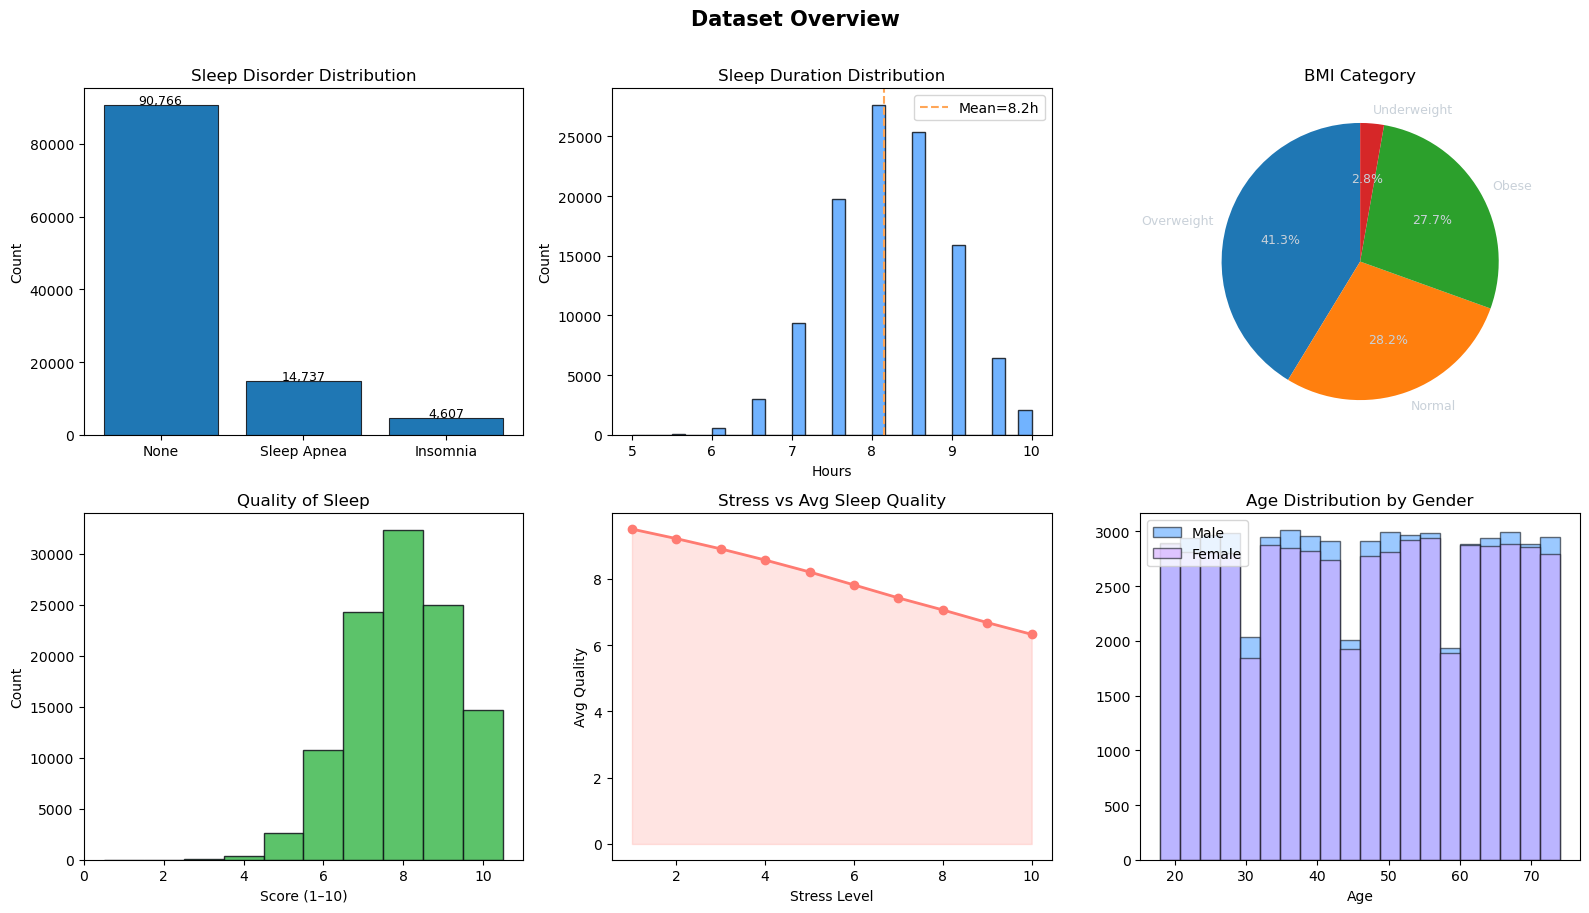

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Dataset Overview", fontsize=15, fontweight='bold', y=1.01)

# 1. Sleep Disorder distribution
disorder_counts = df['Sleep_Disorder'].value_counts()
bars = axes[0,0].bar(disorder_counts.index, disorder_counts.values, edgecolor='#21262d', linewidth=0.8)
axes[0,0].set_title("Sleep Disorder Distribution")
axes[0,0].set_ylabel("Count")
for b in bars:
    axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                   f'{b.get_height():,}', ha='center', fontsize=9)
# 2. Sleep Duration histogram
axes[0,1].hist(df['Sleep_Duration_Hours'], bins=30, color='#58a6ff',
               edgecolor='#0d1117', alpha=0.85)
axes[0,1].set_title("Sleep Duration Distribution")
axes[0,1].set_xlabel("Hours")
axes[0,1].set_ylabel("Count")
axes[0,1].axvline(df['Sleep_Duration_Hours'].mean(), color='#ffa657',
                  linestyle='--', label=f"Mean={df['Sleep_Duration_Hours'].mean():.1f}h")
axes[0,1].legend()

# 3. BMI Category pie
bmi_counts = df['BMI_Category'].value_counts()
axes[0,2].pie(bmi_counts.values, labels=bmi_counts.index, autopct='%1.1f%%', startangle=90,
              textprops={'color':'#c9d1d9', 'fontsize':9})
axes[0,2].set_title("BMI Category")

# 4. Quality of Sleep distribution
axes[1,0].hist(df['Quality_of_Sleep'], bins=range(1,12), color='#3fb950',
               edgecolor='#0d1117', alpha=0.85, align='left')
axes[1,0].set_title("Quality of Sleep")
axes[1,0].set_xlabel("Score (1–10)")
axes[1,0].set_ylabel("Count")

# 5. Stress Level vs Quality of Sleep
stress_quality = df.groupby('Stress_Level')['Quality_of_Sleep'].mean()
axes[1,1].plot(stress_quality.index, stress_quality.values,
               color='#ff7b72', marker='o', linewidth=2, markersize=6)
axes[1,1].fill_between(stress_quality.index, stress_quality.values, alpha=0.2, color='#ff7b72')
axes[1,1].set_title("Stress vs Avg Sleep Quality")
axes[1,1].set_xlabel("Stress Level")
axes[1,1].set_ylabel("Avg Quality")

# 6. Age distribution by gender
for gender, color in zip(['Male','Female'], ['#58a6ff','#d2a8ff']):
    sub = df[df['Gender']==gender]['Age']
    axes[1,2].hist(sub, bins=20, alpha=0.6, label=gender, color=color, edgecolor='#0d1117')
axes[1,2].set_title("Age Distribution by Gender")
axes[1,2].set_xlabel("Age")
axes[1,2].legend()

plt.tight_layout()
plt.show()

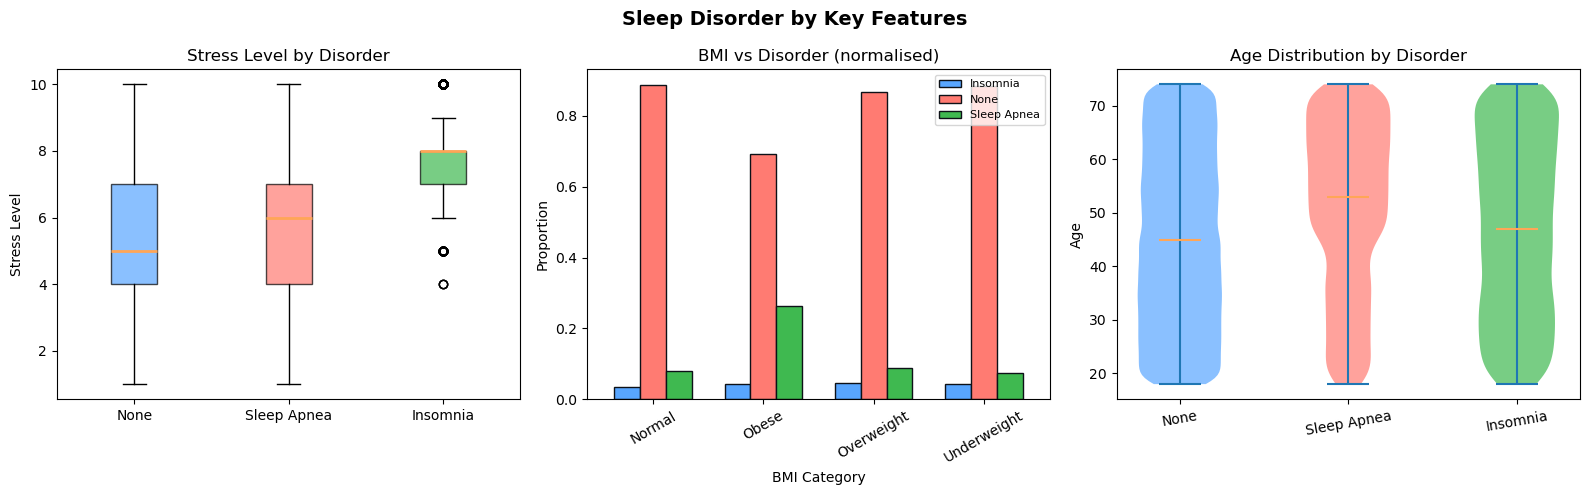

In [12]:
PALETTE = ['#58a6ff', '#ff7b72', '#3fb950']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sleep Disorder by Key Features", fontsize=14, fontweight='bold')

# 3a. Stress level boxplot per disorder
disorders = df['Sleep_Disorder'].unique()
data_box = [df[df['Sleep_Disorder']==d]['Stress_Level'].values for d in disorders]
bp = axes[0].boxplot(data_box, tick_labels=disorders, patch_artist=True,
                     medianprops={'color':'#ffa657','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title("Stress Level by Disorder")
axes[0].set_ylabel("Stress Level")

# 3b. BMI × Disorder stacked bar
ct = pd.crosstab(df['BMI_Category'], df['Sleep_Disorder'], normalize='index')
ct.plot(kind='bar', ax=axes[1], color=PALETTE[:len(ct.columns)],
        edgecolor='#0d1117', width=0.7)
axes[1].set_title("BMI vs Disorder (normalised)")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("BMI Category")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

# 3c. Age violin
import warnings
warnings.filterwarnings('ignore')
# Build age groups safely
age_groups = [
    df[df['Sleep_Disorder'] == d]['Age'].dropna().values
    for d in disorders
]

# Filter out empty groups
valid = [(d, g) for d, g in zip(disorders, age_groups) if len(g) > 0]
valid_disorders, valid_groups = zip(*valid)

parts = axes[2].violinplot(
    valid_groups,
    positions=range(len(valid_groups)),
    showmedians=True
)

# Color bodies
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)

parts['cmedians'].set_color('#ffa657')

axes[2].set_xticks(range(len(valid_disorders)))
axes[2].set_xticklabels(valid_disorders, rotation=10)
axes[2].set_title("Age Distribution by Disorder")
axes[2].set_ylabel("Age")


plt.tight_layout()
plt.show()

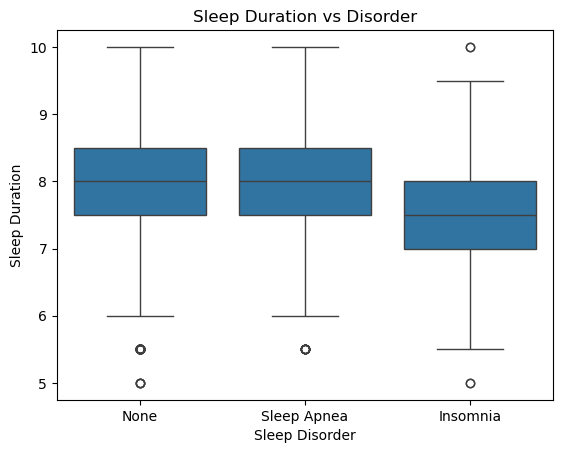

In [13]:
sns.boxplot(x="Sleep_Disorder", y="Sleep_Duration_Hours", data=df)
plt.title("Sleep Duration vs Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Sleep Duration")
plt.show()

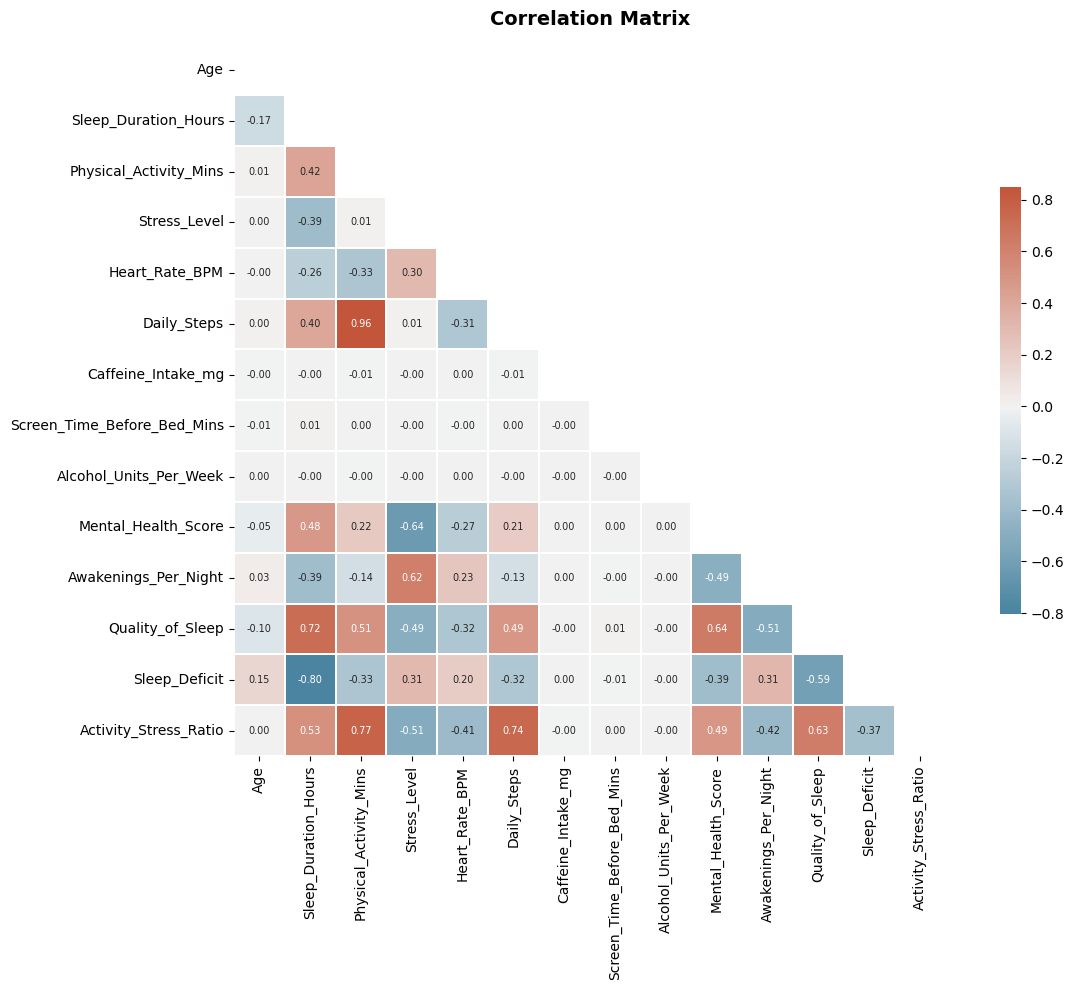

In [14]:
num_cols = ['Age','Sleep_Duration_Hours','Physical_Activity_Mins','Stress_Level',
            'Heart_Rate_BPM','Daily_Steps','Caffeine_Intake_mg',
            'Screen_Time_Before_Bed_Mins','Alcohol_Units_Per_Week',
            'Mental_Health_Score','Awakenings_Per_Night','Quality_of_Sleep',
            'Sleep_Deficit','Activity_Stress_Ratio']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.85, center=0,
            annot=True, fmt='.2f', annot_kws={'size':7},
            square=True, linewidths=0.3,
            cbar_kws={'shrink':.6}, ax=ax)
ax.set_title("Correlation Matrix", fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [12]:
# Encode target
le = LabelEncoder()
df["Sleep_Disorder"] = le.fit_transform(df["Sleep_Disorder"])

# Show mapping
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Sleep_Disorder Encoding Map:")
for k, v in label_map.items():
    print(f"  {k} → {v}")

# Target distribution
print(df['Sleep_Disorder'].value_counts(normalize=True))

df.head()


Sleep_Disorder Encoding Map:
  Insomnia → 0
  None → 1
  Sleep Apnea → 2
Sleep_Disorder
1    0.824321
2    0.133839
0    0.041840
Name: proportion, dtype: float64


,Person_ID,Record_Date,Is_Weekend,Gender,Age,Occupation,BMI_Value,BMI_Category,Smoking_Status,Sleep_Duration_Hours,...,Diastolic_BP,Daily_Steps,Caffeine_Intake_mg,Screen_Time_Before_Bed_Mins,Alcohol_Units_Per_Week,Room_Temperature_C,Noise_Level_dB,Sleep_Disorder,Sleep_Deficit,Activity_Stress_Ratio
0,1,12/8/2023,0,Male,39,Manager,24.6,Normal,Never,7.5,...,87,4299,85,102,0.7,15.2,20,1,0.5,4.00
1,2,4/26/2020,0,Female,30,Police Officer,25.3,Overweight,Never,10.0,...,69,9369,158,93,5.6,20.4,43,1,0.0,11.40
2,3,1/11/2023,1,Female,71,Engineer,26.6,Overweight,Never,8.5,...,85,9379,64,51,2.9,13.7,31,1,0.0,11.33
3,4,3/25/2022,0,Female,22,Teacher,29.6,Overweight,Current,8.5,...,80,5937,68,78,0.5,23.2,41,1,0.0,5.67
4,5,6/11/2022,0,Male,63,Accountant,26.1,Overweight,Never,6.0,...,80,500,117,106,0.6,20.3,23,1,2.0,0.50


In [13]:
FEATURES = [
    "Age","Gender","Occupation","BMI_Category","Smoking_Status",
    "Sleep_Duration_Hours","Physical_Activity_Mins","Stress_Level",
    "Heart_Rate_BPM","Daily_Steps","Caffeine_Intake_mg",
    "Screen_Time_Before_Bed_Mins","Alcohol_Units_Per_Week",
    "Room_Temperature_C","Noise_Level_dB","Work_Hours_Per_Day",
    "Exercise_Type","Mental_Health_Score","Awakenings_Per_Night",
    "Nap_Duration_Mins","Is_Weekend","Sleep_Deficit","Activity_Stress_Ratio"
]

TARGET_CLASS = "Sleep_Disorder"
TARGET_REG = "Quality_of_Sleep"

NUM = df[FEATURES].select_dtypes(include=np.number).columns.tolist()
CAT = list(set(FEATURES) - set(NUM))


In [14]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM),
    ("cat", cat_pipe, CAT)
])


In [15]:
df[TARGET_CLASS].isna().sum()
df[TARGET_CLASS].unique()


array([1, 2, 0])

In [16]:
df = df.dropna(subset=[TARGET_CLASS])

X = df[FEATURES]
y = df[TARGET_CLASS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=150, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN":                KNeighborsClassifier(n_neighbors=9, n_jobs=-1)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })
    

In [28]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1 Score
0,Random Forest,0.824357,0.746005
1,Gradient Boosting,0.823994,0.745236
2,Logistic Regression,0.823404,0.746601
3,KNN,0.817137,0.748978


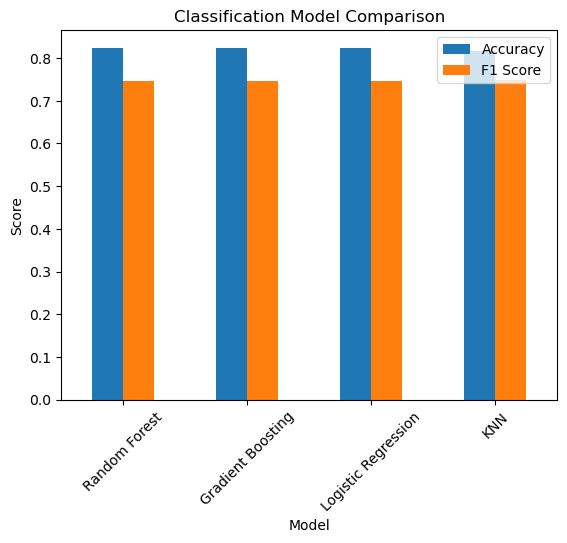

In [29]:
results_df.set_index("Model")[["Accuracy","F1 Score"]].plot(kind="bar")
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [30]:
best_model_name = results_df.sort_values("F1 Score", ascending=False)["Model"].iloc[0]
print("Best model:", best_model_name)

Best model: KNN


In [50]:
y_reg = df[TARGET_REG] 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# 3. Run the regression loop
reg_results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train_r, y_train_r)
    preds = pipe.predict(X_test_r)
    
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_r, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, preds)),
        "R2": r2_score(y_test_r, preds)
    })

In [51]:
reg_df = pd.DataFrame(reg_results)
reg_df

,Model,MAE,RMSE,R2
0,Random Forest,0.502089,0.760152,0.650655
1,Gradient Boosting,0.492280,0.748595,0.661197
2,Logistic Regression,0.481064,0.737133,0.671492
3,KNN,0.610707,0.876151,0.535900


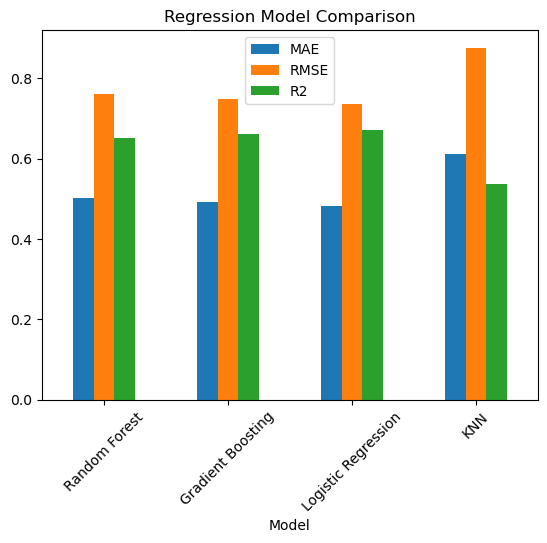

In [52]:
reg_df.set_index("Model")[["MAE","RMSE","R2"]].plot(kind="bar")
plt.title("Regression Model Comparison")
plt.xticks(rotation=45)
plt.show()

In [56]:
best_reg = reg_df.sort_values("R2", ascending=False)["Model"].iloc[0]
print("Best regression model:", best_reg)

Best regression model: Logistic Regression


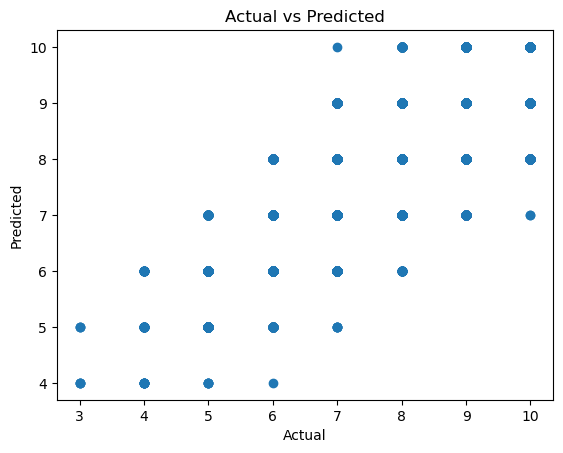

In [57]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", models[best_reg])
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

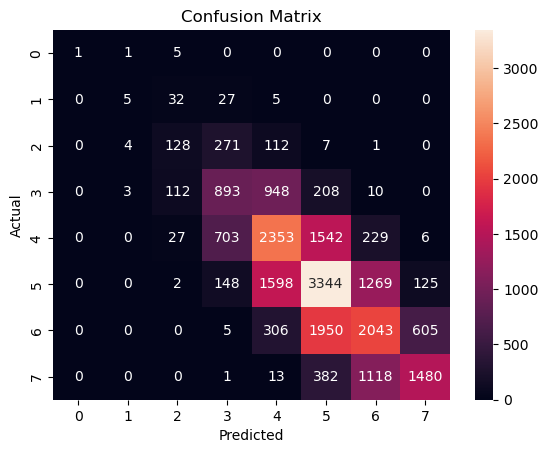

In [54]:
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

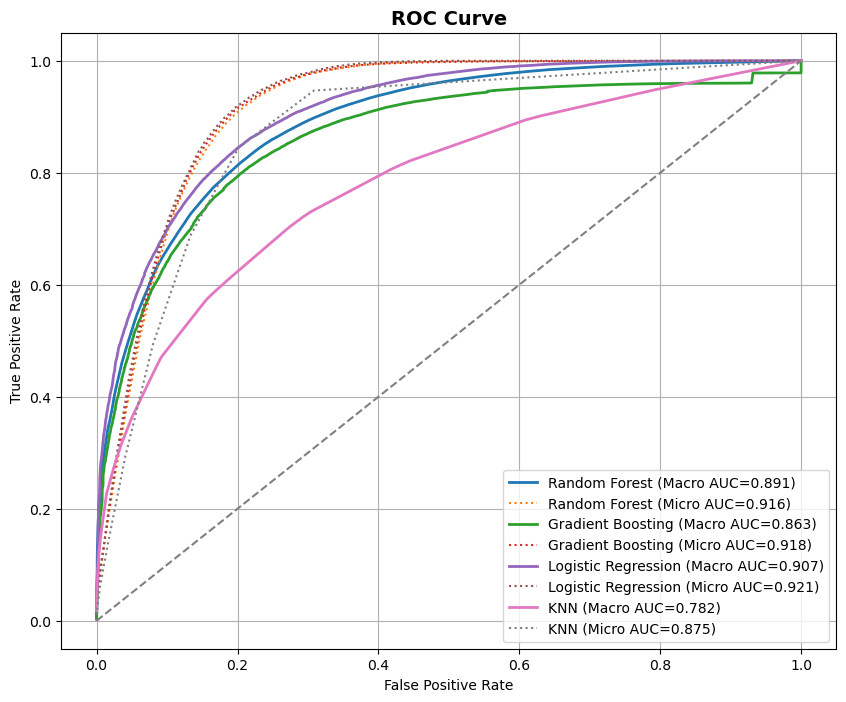

In [63]:
# Fit pipelines
fitted_pipes = {
    name: Pipeline([("prep", preprocessor), ("model", model)]).fit(X_train, y_train)
    for name, model in models.items()
}

# Binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_bin.shape[1]

plt.figure(figsize=(10, 8))
plt.title("ROC Curve", fontsize=14, fontweight="bold")

for name, pipe in fitted_pipes.items():

    model = pipe.named_steps["model"]
    if not hasattr(model, "predict_proba"):
        continue

    y_score = pipe.predict_proba(X_test)

    # Macro-average ROC
    fprs, tprs = zip(*[
        roc_curve(y_bin[:, i], y_score[:, i])[:2]
        for i in range(n_classes)
    ])

    all_fpr = np.unique(np.concatenate(fprs))
    mean_tpr = np.mean([
        np.interp(all_fpr, fpr, tpr)
        for fpr, tpr in zip(fprs, tprs)
    ], axis=0)

    macro_auc = auc(all_fpr, mean_tpr)

    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    micro_auc = auc(fpr_micro, tpr_micro)

    # Plot
    plt.plot(all_fpr, mean_tpr, lw=2, label=f"{name} (Macro AUC={macro_auc:.3f})")
    plt.plot(fpr_micro, tpr_micro, linestyle=":", label=f"{name} (Micro AUC={micro_auc:.3f})")

# Baseline
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

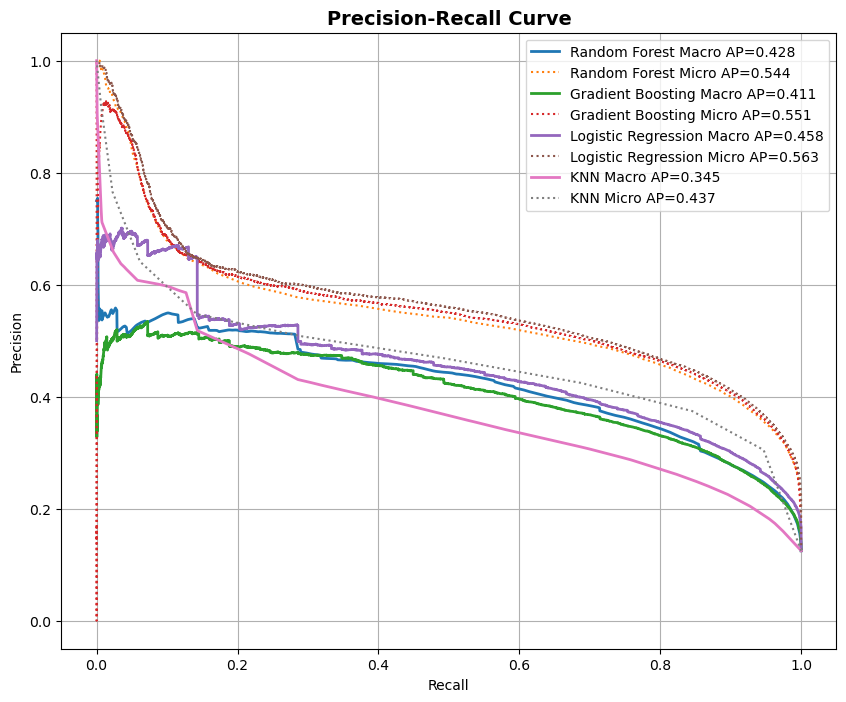

In [66]:
# Binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_bin.shape[1]

plt.figure(figsize=(10, 8))
plt.title("Precision-Recall Curve", fontsize=14, fontweight="bold")

for name, pipe in fitted_pipes.items():

    model = pipe.named_steps["model"]
    if not hasattr(model, "predict_proba"):
        continue

    y_score = pipe.predict_proba(X_test)

    # Macro-average PR
    precisions, recalls = zip(*[
        precision_recall_curve(y_bin[:, i], y_score[:, i])[:2]
        for i in range(n_classes)
    ])

    all_recalls = np.unique(np.concatenate(recalls))
    mean_precision = np.mean([
        np.interp(all_recalls, r[::-1], p[::-1])  # reverse for increasing recall
        for p, r in zip(precisions, recalls)
    ], axis=0)

    macro_ap = average_precision_score(y_bin, y_score, average="macro")

    # Micro-average PR
    precision_micro, recall_micro, _ = precision_recall_curve(
        y_bin.ravel(), y_score.ravel()
    )
    micro_ap = average_precision_score(y_bin, y_score, average="micro")

    # Plot
    plt.plot(all_recalls, mean_precision, lw=2,
             label=f"{name} Macro AP={macro_ap:.3f}")

    plt.plot(recall_micro, precision_micro, linestyle=":",
             label=f"{name} Micro AP={micro_ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.show()

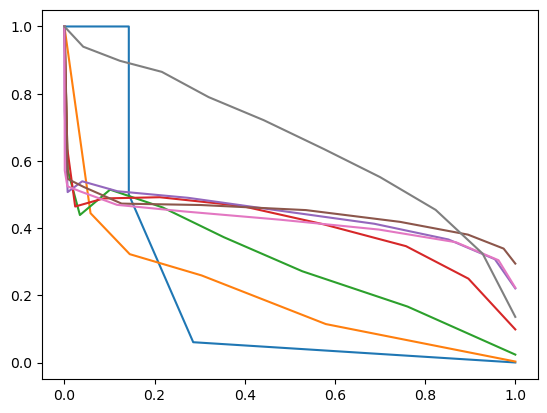

In [65]:
for i in range(n_classes):
    p, r, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_bin[:, i], y_score[:, i])
    plt.plot(r, p, label=f"Class {i} (AP={ap:.2f})")